# Q4 — Engagement vs. Informational Quality (CoAID)
**Research Question:** Are engagement-optimized signals negatively correlated with informational quality across policy topics?

Uses the CoAID (COVID-19 Healthcare Misinformation Dataset), specifically the `05-01-2020` snapshot.  
Data directory expected at: `./CoAID/05-01-2020/`

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu

sns.set_theme(style='whitegrid', palette='muted')

DATA_DIR = Path.cwd() / 'CoAID' / '05-01-2020'

fake_tweets = pd.read_csv(DATA_DIR / 'NewsFakeCOVID-19_tweets.csv')
real_tweets = pd.read_csv(DATA_DIR / 'NewsRealCOVID-19_tweets.csv')

print('Fake tweets shape:', fake_tweets.shape)
print('Real tweets shape:', real_tweets.shape)
print(fake_tweets.head())

Fake tweets shape: (9218, 2)
Real tweets shape: (87324, 2)
   index             tweet_id
0     55  1255263076087185413
1     55  1254390256461365248
2     55  1253279600119033856
3     55  1252271897850544131
4     55  1251308087467802624


In [2]:
fake_counts = fake_tweets.groupby('index').size()
real_counts = real_tweets.groupby('index').size()

print(f'Fake news articles: n={len(fake_counts)}')
print(f'  Mean tweets:   {fake_counts.mean():.2f}')
print(f'  Median tweets: {fake_counts.median():.2f}')
print(f'  Std:           {fake_counts.std():.2f}')
print()
print(f'Real news articles: n={len(real_counts)}')
print(f'  Mean tweets:   {real_counts.mean():.2f}')
print(f'  Median tweets: {real_counts.median():.2f}')
print(f'  Std:           {real_counts.std():.2f}')

Fake news articles: n=72
  Mean tweets:   128.03
  Median tweets: 46.00
  Std:           161.40

Real news articles: n=1449
  Mean tweets:   60.27
  Median tweets: 16.00
  Std:           123.15


In [3]:
t_stat, p_value = ttest_ind(fake_counts, real_counts, equal_var=False)

u_stat, p_mwu = mannwhitneyu(fake_counts, real_counts, alternative='two-sided')

cohens_d = (fake_counts.mean() - real_counts.mean()) / np.sqrt(
    (fake_counts.std()**2 + real_counts.std()**2) / 2
)

print('=== Statistical Tests ===')
print(f"Welch's t-test:    t = {t_stat:.3f},  p = {p_value:.4e}")
print(f'Mann-Whitney U:    U = {u_stat:.0f},  p = {p_mwu:.4e}')
print(f"Cohen's d:         {cohens_d:.3f}")
print(f"Significant (α=0.05): {p_value < 0.05}")

=== Statistical Tests ===
Welch's t-test:    t = 3.512,  p = 7.5590e-04
Mann-Whitney U:    U = 62478,  p = 4.5600e-03
Cohen's d:         0.472
Significant (α=0.05): True


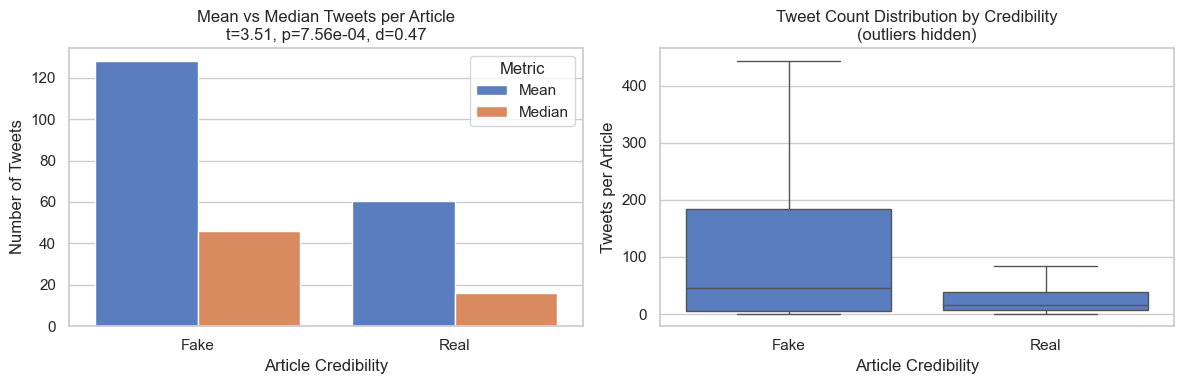

Fig 1 saved to q4_coaid_engagement.png


In [4]:
# Mean vs Median tweets per article by credibility
summary_df = pd.DataFrame({
    'type':   ['Fake', 'Real', 'Fake', 'Real'],
    'metric': ['Mean', 'Mean', 'Median', 'Median'],
    'value':  [
        fake_counts.mean(), real_counts.mean(),
        fake_counts.median(), real_counts.median()
    ]
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
sns.barplot(data=summary_df, x='type', y='value', hue='metric', ax=axes[0])
axes[0].set_title(
    f'Mean vs Median Tweets per Article\n'
    f't={t_stat:.2f}, p={p_value:.2e}, d={cohens_d:.2f}'
)
axes[0].set_xlabel('Article Credibility')
axes[0].set_ylabel('Number of Tweets')
axes[0].legend(title='Metric')

# Box plot (shows distribution shape, not just central tendency)
plot_data = pd.concat([
    fake_counts.rename('tweets').to_frame().assign(type='Fake'),
    real_counts.rename('tweets').to_frame().assign(type='Real')
])
sns.boxplot(data=plot_data, x='type', y='tweets', ax=axes[1],
            showfliers=False)  # hide extreme outliers for readability
axes[1].set_title('Tweet Count Distribution by Credibility\n(outliers hidden)')
axes[1].set_xlabel('Article Credibility')
axes[1].set_ylabel('Tweets per Article')

plt.tight_layout()
plt.savefig('q4_coaid_engagement.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 1 saved to q4_coaid_engagement.png')

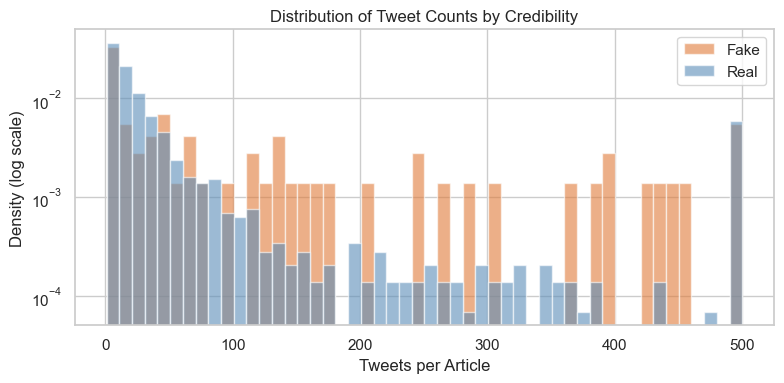

Fig 2 saved to q4_coaid_distribution.png


In [5]:
# Distribution of tweet counts
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(fake_counts, bins=50, alpha=0.6, label='Fake', color='#e07b39', density=True)
ax.hist(real_counts, bins=50, alpha=0.6, label='Real', color='#5b8db8', density=True)
ax.set_yscale('log')
ax.set_xlabel('Tweets per Article')
ax.set_ylabel('Density (log scale)')
ax.set_title('Distribution of Tweet Counts by Credibility')
ax.legend()

plt.tight_layout()
plt.savefig('q4_coaid_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 2 saved to q4_coaid_distribution.png')

In [6]:
summary_table = pd.DataFrame({
    'Credibility': ['Fake', 'Real'],
    'N Articles':  [len(fake_counts), len(real_counts)],
    'Mean Tweets': [round(fake_counts.mean(), 1), round(real_counts.mean(), 1)],
    'Median Tweets': [fake_counts.median(), real_counts.median()],
    'Std':          [round(fake_counts.std(), 1), round(real_counts.std(), 1)],
})
print(summary_table.to_string(index=False))
print()
print(f"Welch's t-test: t={t_stat:.3f}, p={p_value:.4e}")
print(f"Mann-Whitney U: U={u_stat:.0f}, p={p_mwu:.4e}")
print(f"Cohen's d: {cohens_d:.3f}")

Credibility  N Articles  Mean Tweets  Median Tweets   Std
       Fake          72        128.0           46.0 161.4
       Real        1449         60.3           16.0 123.1

Welch's t-test: t=3.512, p=7.5590e-04
Mann-Whitney U: U=62478, p=4.5600e-03
Cohen's d: 0.472
